# Imports and definitions

In [2]:
# imports
from matplotlib.ticker import ScalarFormatter
from scipy.integrate import simpson
from kuibit.simdir import SimDir
import matplotlib.pyplot as plt
from tabulate import tabulate
import matplotlib.cm as cm
from numpy import sqrt
import numpy as np
import os

In [3]:
# display dynamical plots
%matplotlib widget

In [4]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl /home/undercover/projects/cactus/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# $\alpha = 0$

In [3]:
sd           = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0-x0=4.001_h=2.5")
ts           = sd.timeseries
gf           = sd.gf
hc_norm      = ts.norm2["hc"]
Ec_norm      = ts.norm2["Ec"]
Bc_norm      = ts.norm2["Bc"]

sd_res2      = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0-x0=4.001_h=3")
ts_res2      = sd_res2.timeseries
gf_res2      = sd_res2.gf
hc_norm_res2 = ts_res2.norm2["hc"]
Ec_norm_res2 = ts_res2.norm2["Ec"]
Bc_norm_res2 = ts_res2.norm2["Bc"]

/tmp/ipykernel_1837497/3247202741.py:43: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax[1,0].set_yscale("log")


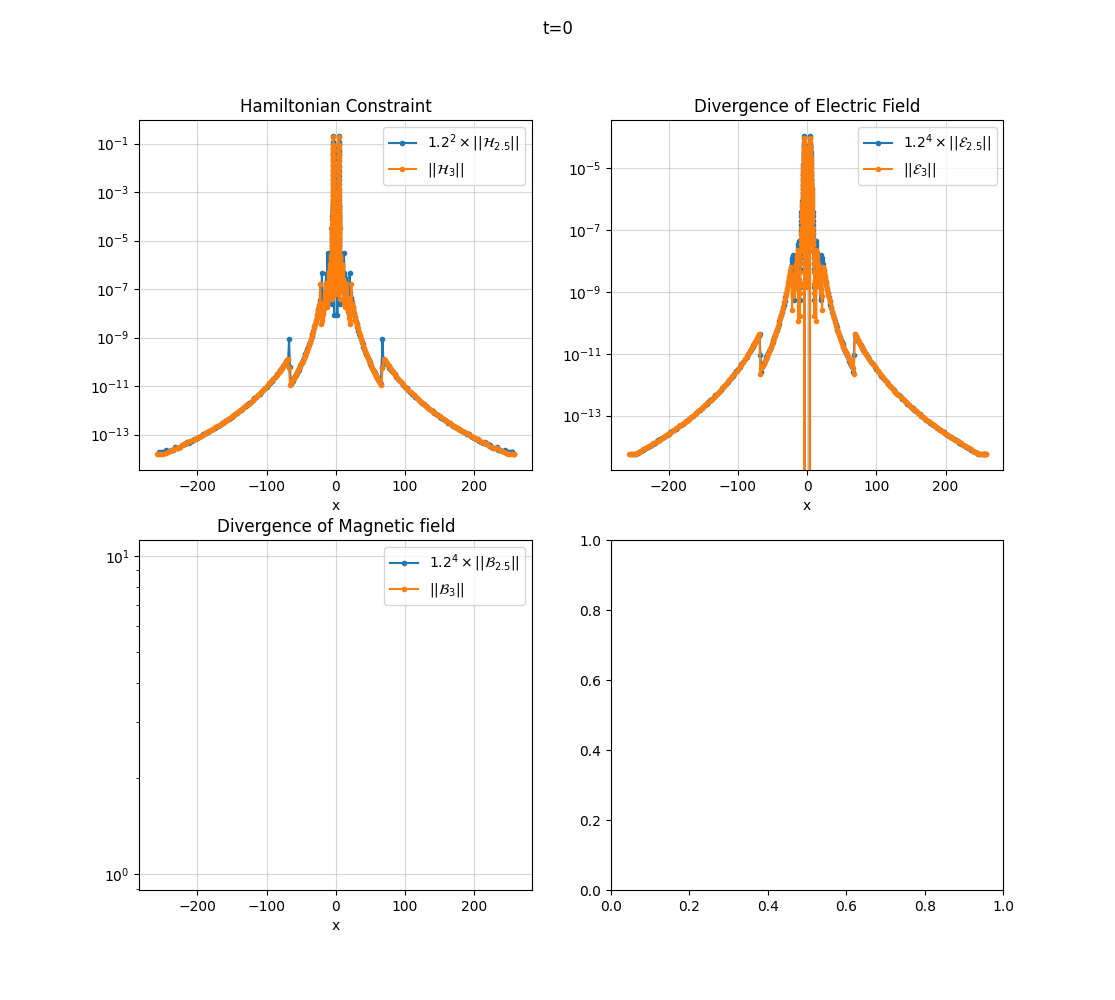

In [12]:
t    = 0  # pick time step here
axis = "x"

fig, ax = plt.subplots(2, 2, figsize=(11.15,10))

fig.suptitle(f"t={t}")


coor_1, data_1 = GetMesh(sd,      "hc", axis)
coor_2, data_2 = GetMesh(sd_res2, "hc", axis)

ax[0,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^2 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{H}_{3}  ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel(axis)
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


coor_1, data_1 = GetMesh(sd,      "Ec", axis)
coor_2, data_2 = GetMesh(sd_res2, "Ec", axis)

ax[0,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel(axis)
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


coor_1, data_1 = GetMesh(sd,      "Bc", axis)
coor_2, data_2 = GetMesh(sd_res2, "Bc", axis)

ax[1,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel(axis)
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic field")
ax[1,0].legend();

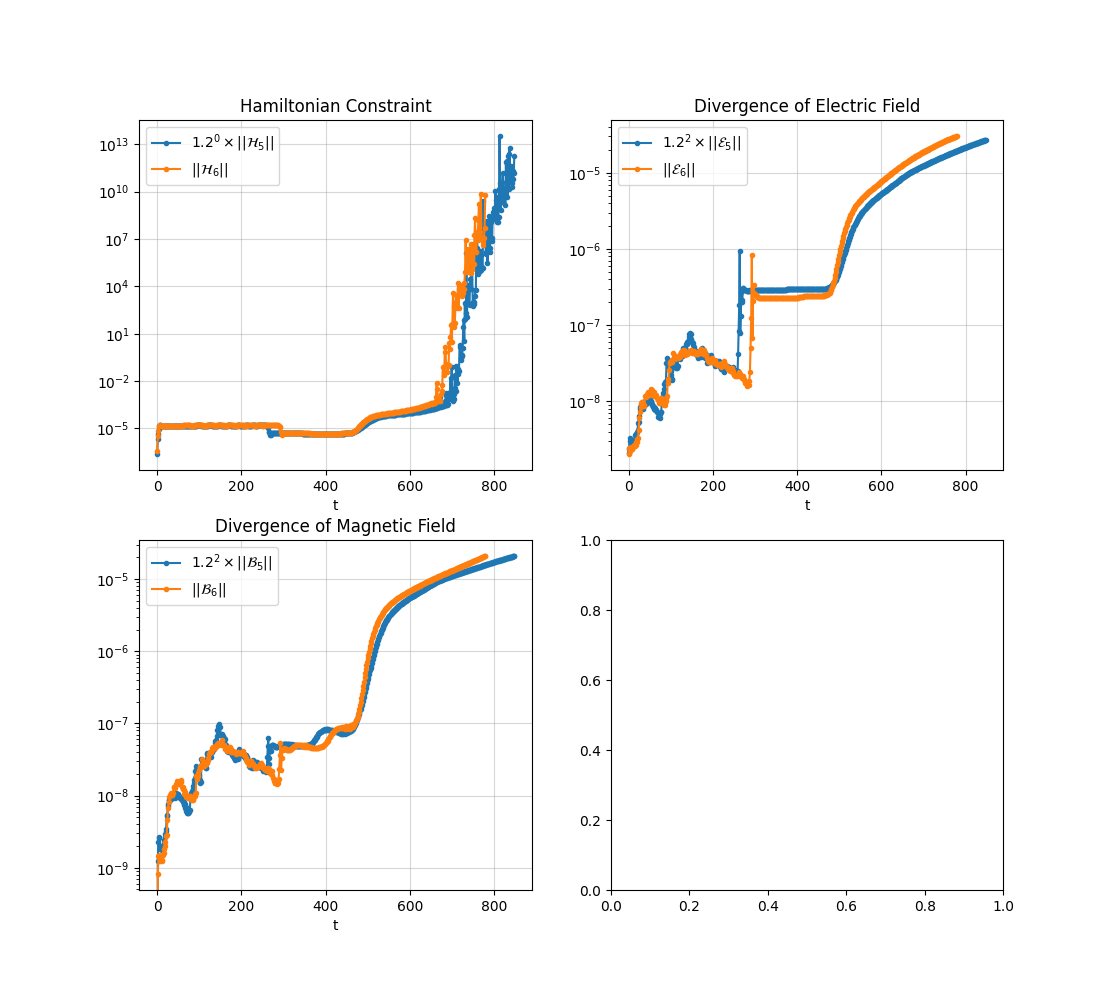

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(11.15,10))


ax[0,0].plot(hc_norm.t,      1.2**1*hc_norm.y,      marker=".", label=r"$1.2^0 \times ||\mathcal{H}_{5}||$")
ax[0,0].plot(hc_norm_res2.t,        hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{6}||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      1.2**2*Ec_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{E}_{5}||$")
ax[0,1].plot(Ec_norm_res2.t,        Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{6}||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      1.2**2*Bc_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{B}_{5}||$")
ax[1,0].plot(Bc_norm_res2.t,        Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{6}||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();

# $\alpha = \pi/4$

In [5]:
sd           = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0.25pi-x0=4.001_h=2.5")
ts           = sd.timeseries
gf           = sd.gf
hc_norm      = ts.norm2["hc"]
Ec_norm      = ts.norm2["Ec"]
Bc_norm      = ts.norm2["Bc"]

sd_res2      = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0.25pi-x0=4.001_h=3")
ts_res2      = sd_res2.timeseries
gf_res2      = sd_res2.gf
hc_norm_res2 = ts_res2.norm2["hc"]
Ec_norm_res2 = ts_res2.norm2["Ec"]
Bc_norm_res2 = ts_res2.norm2["Bc"]

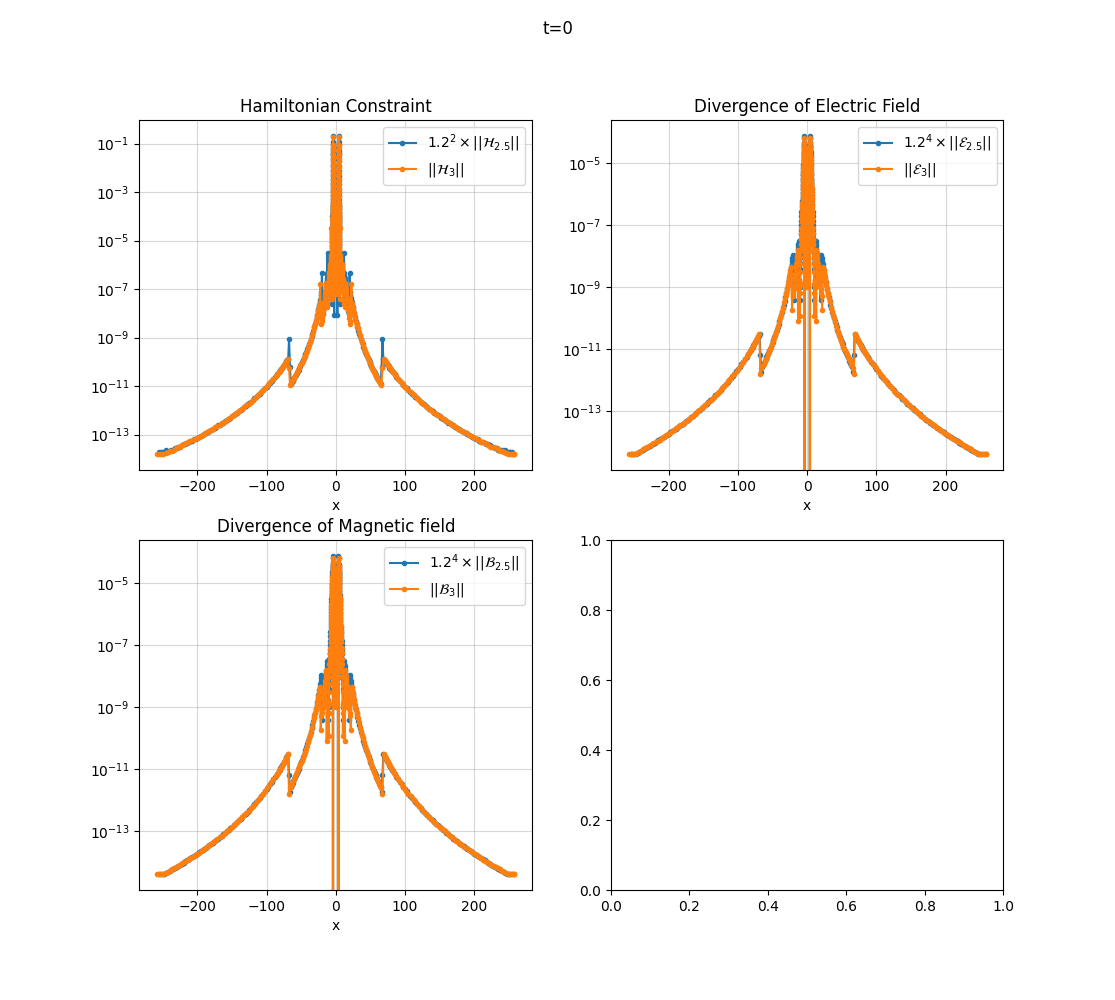

In [6]:
t    = 0  # pick time step here
axis = "x"

fig, ax = plt.subplots(2, 2, figsize=(11.15,10))

fig.suptitle(f"t={t}")


coor_1, data_1 = GetMesh(sd,      "hc", axis)
coor_2, data_2 = GetMesh(sd_res2, "hc", axis)

ax[0,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^2 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{H}_{3}  ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel(axis)
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


coor_1, data_1 = GetMesh(sd,      "Ec", axis)
coor_2, data_2 = GetMesh(sd_res2, "Ec", axis)

ax[0,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel(axis)
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


coor_1, data_1 = GetMesh(sd,      "Bc", axis)
coor_2, data_2 = GetMesh(sd_res2, "Bc", axis)

ax[1,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel(axis)
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic field")
ax[1,0].legend();

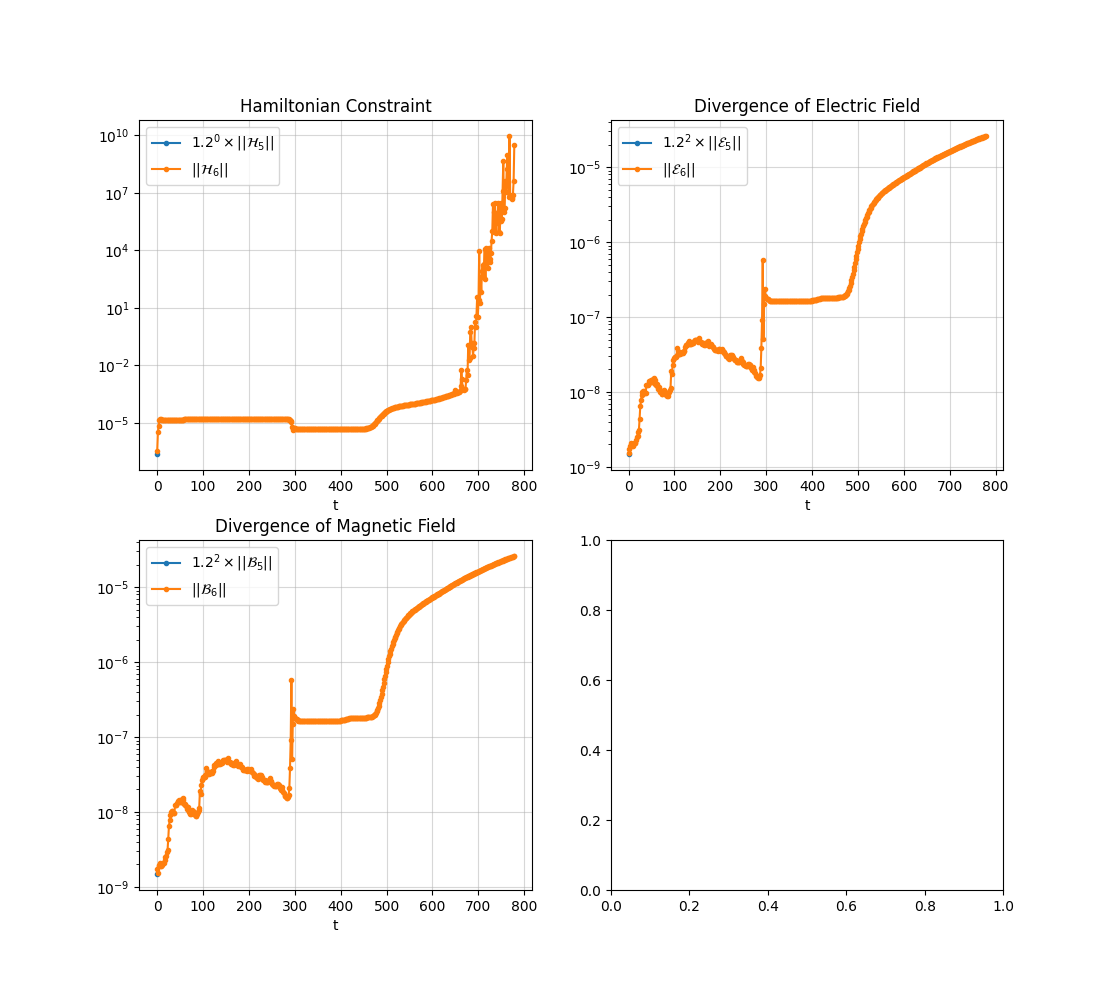

In [7]:
fig, ax = plt.subplots(2, 2, figsize=(11.15,10))


ax[0,0].plot(hc_norm.t,      1.2**1*hc_norm.y,      marker=".", label=r"$1.2^0 \times ||\mathcal{H}_{5}||$")
ax[0,0].plot(hc_norm_res2.t,        hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{6}||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      1.2**2*Ec_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{E}_{5}||$")
ax[0,1].plot(Ec_norm_res2.t,        Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{6}||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      1.2**2*Bc_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{B}_{5}||$")
ax[1,0].plot(Bc_norm_res2.t,        Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{6}||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();

# $\alpha = \pi/2$

In [8]:
sd           = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0.5pi-x0=4.001_h=2.5")
ts           = sd.timeseries
gf           = sd.gf
hc_norm      = ts.norm2["hc"]
Ec_norm      = ts.norm2["Ec"]
Bc_norm      = ts.norm2["Bc"]

sd_res2      = SimDir("../simulations/Merger_BSSN_m=0.5,0.5-q=0.25,0.25-alpha=0.5pi-x0=4.001_h=3")
ts_res2      = sd_res2.timeseries
gf_res2      = sd_res2.gf
hc_norm_res2 = ts_res2.norm2["hc"]
Ec_norm_res2 = ts_res2.norm2["Ec"]
Bc_norm_res2 = ts_res2.norm2["Bc"]

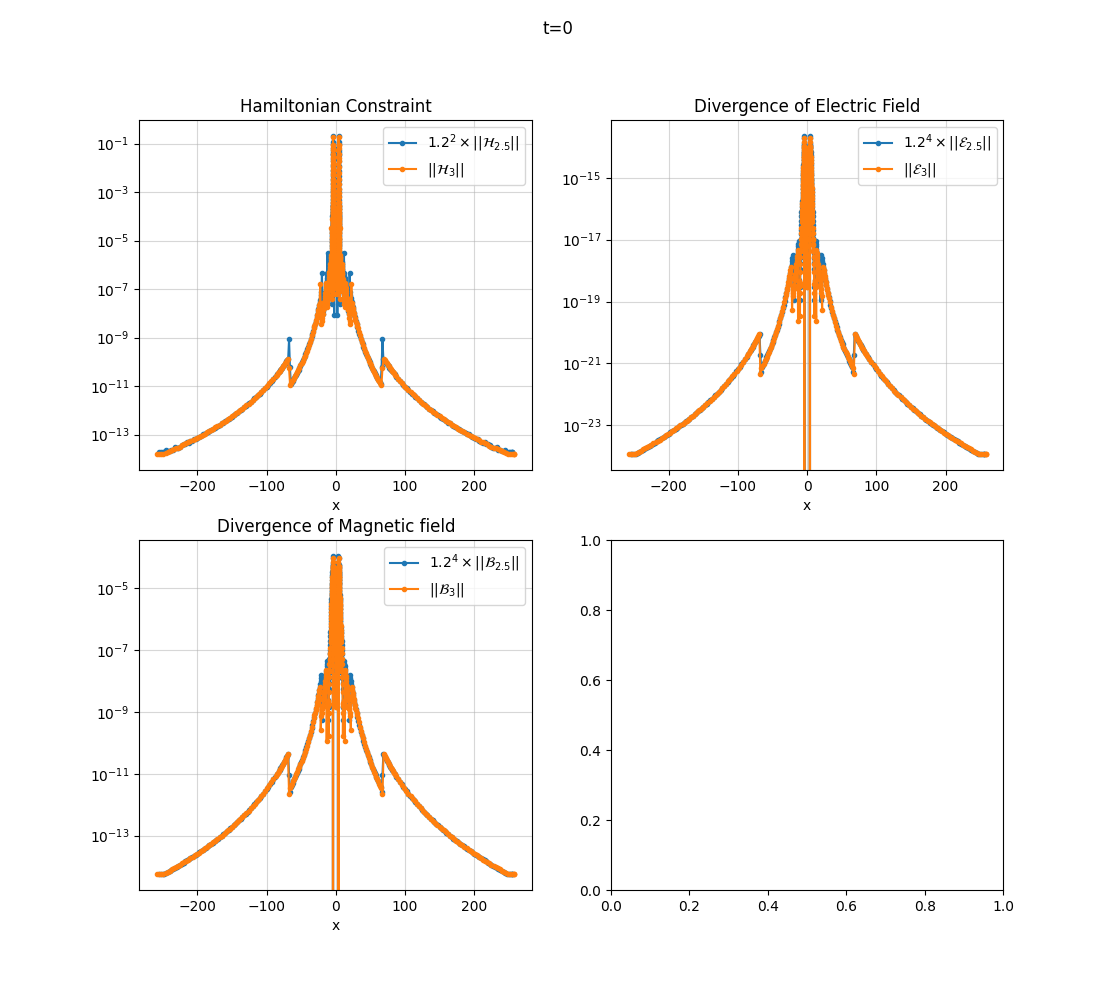

In [9]:
t    = 0  # pick time step here
axis = "x"

fig, ax = plt.subplots(2, 2, figsize=(11.15,10))

fig.suptitle(f"t={t}")


coor_1, data_1 = GetMesh(sd,      "hc", axis)
coor_2, data_2 = GetMesh(sd_res2, "hc", axis)

ax[0,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^2 \times ||\mathcal{H}_{2.5}||$")
ax[0,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{H}_{3}  ||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel(axis)
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


coor_1, data_1 = GetMesh(sd,      "Ec", axis)
coor_2, data_2 = GetMesh(sd_res2, "Ec", axis)

ax[0,1].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{E}_{2.5}||$")
ax[0,1].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{E}_{3}  ||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel(axis)
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


coor_1, data_1 = GetMesh(sd,      "Bc", axis)
coor_2, data_2 = GetMesh(sd_res2, "Bc", axis)

ax[1,0].plot(coor_1[f"t={t}"], 1.2**4*abs(data_1[f"t={t}"]), marker=".", label=r"$1.2^4 \times ||\mathcal{B}_{2.5}||$")
ax[1,0].plot(coor_2[f"t={t}"],        abs(data_2[f"t={t}"]), marker=".", label=r"$             ||\mathcal{B}_{3}  ||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel(axis)
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic field")
ax[1,0].legend();

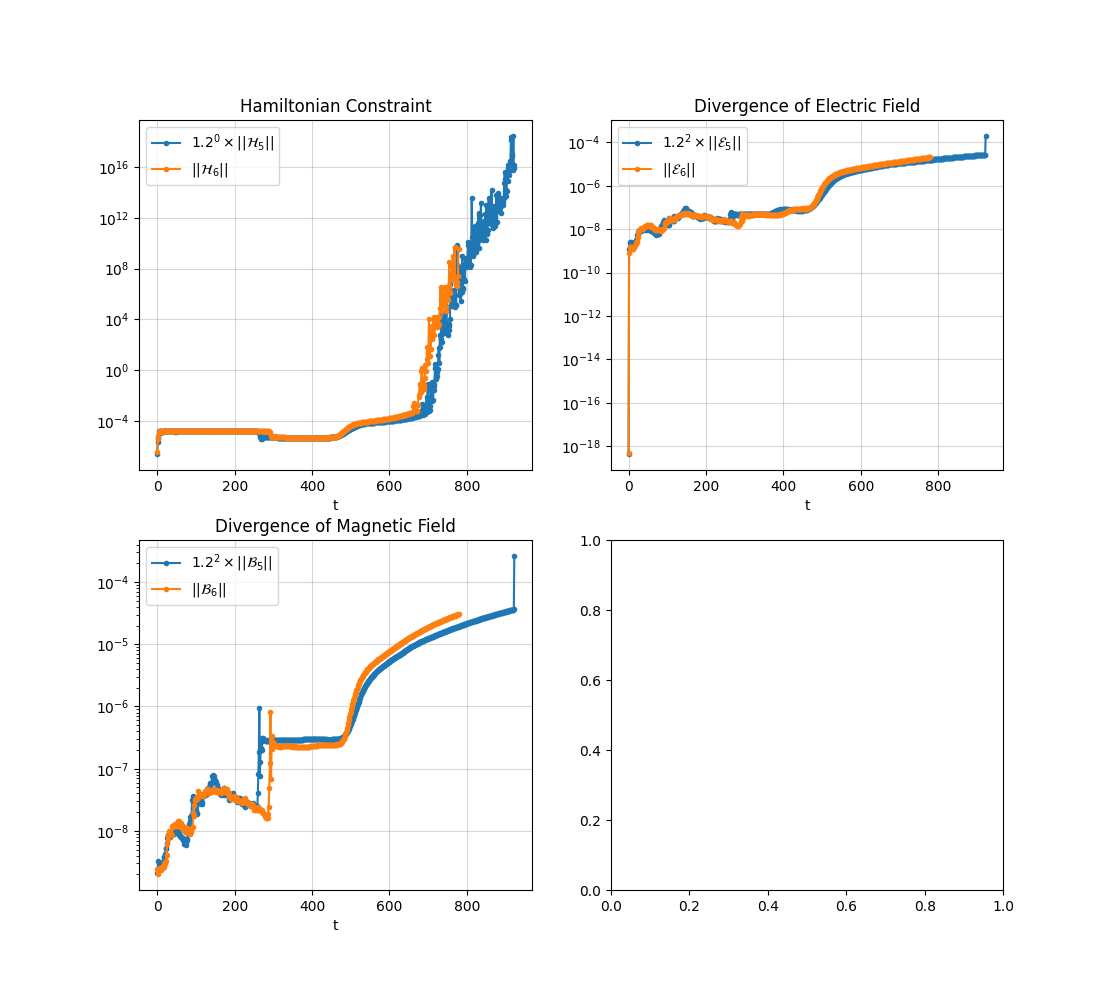

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(11.15,10))


ax[0,0].plot(hc_norm.t,      1.2**1*hc_norm.y,      marker=".", label=r"$1.2^0 \times ||\mathcal{H}_{5}||$")
ax[0,0].plot(hc_norm_res2.t,        hc_norm_res2.y, marker=".", label=r"$             ||\mathcal{H}_{6}||$")

ax[0,0].grid(alpha=0.5)
ax[0,0].set_xlabel("t")
ax[0,0].set_yscale("log")
ax[0,0].set_title("Hamiltonian Constraint")
ax[0,0].legend()


ax[0,1].plot(Ec_norm.t,      1.2**2*Ec_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{E}_{5}||$")
ax[0,1].plot(Ec_norm_res2.t,        Ec_norm_res2.y, marker=".", label=r"$             ||\mathcal{E}_{6}||$")

ax[0,1].grid(alpha=0.5)
ax[0,1].set_xlabel("t")
ax[0,1].set_yscale("log")
ax[0,1].set_title("Divergence of Electric Field")
ax[0,1].legend()


ax[1,0].plot(Bc_norm.t,      1.2**2*Bc_norm.y,      marker=".", label=r"$1.2^2 \times ||\mathcal{B}_{5}||$")
ax[1,0].plot(Bc_norm_res2.t,        Bc_norm_res2.y, marker=".", label=r"$             ||\mathcal{B}_{6}||$")

ax[1,0].grid(alpha=0.5)
ax[1,0].set_xlabel("t")
ax[1,0].set_yscale("log")
ax[1,0].set_title("Divergence of Magnetic Field")
ax[1,0].legend();